Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_th

## Reading in global data

In [4]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# getting full (nmax=15) unperturbed records and synthetic suite info
record_dict_global, syn_suite_info_global = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=15)



# defining notebook global colours for each mode in plotting
for i, mode_key in enumerate(syn_suite_info_global):
    syn_suite_info_global[mode_key]["colour"] = tol_muted[i % len(tol_muted)]

## Running pipeline (loading data, run DMD, recover modes)

# Results_dict

Results dict is a dictionary containing the results for a single run of DMD.

It is split into 4 kinds of records [record_key]:

- "ideal"
- "resolved"
- "background"
- "ensemble" = ["1", "2", ..., "n_ensemble"]

If a record converged/ obtained modes (i.e. opDMD LS convergence), a result is returned (see below), False if not.

each 'record' result data set stores the following for each mode [record_key]["mode_key"]:

- whether match was made (see below) or not (will be False)
- "match_period" = what is the period of the DMD mode matched
- "period_error" = waht is the fractional error in period to matched mode
- "similarity" = similarity of complex phasor recovered vs true input

as well as the overall modes recovered for that run [record_key]["match_count"]

In [15]:
# running on background field only

gnm_chaos = CHAOS_Full_SV_Record_Obtain()
gnm_background = Non_Wave_Spectral_Infill(gnm_chaos, np.zeros_like(gnm_chaos))

# nmax values to test
nmax_list = np.arange(5, 16, 2)

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":8,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":False,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

num_modes_heat_map = np.zeros((len(nmax_list), len(svd_rank_list)))

# for each nmax to be tested
for n_idx, nmax in enumerate(nmax_list):

    # for each svd rank to be tested
    for r_idx, svd_rank in enumerate(svd_rank_list):

        A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)
        gnm_background_truncate = Truncate_Gauss_Coeffs(gnm_background, tmax=nmax)

        # projecting to grid
        background_record = A_r @ gnm_background_truncate.T
        
        # run DMD on background to get
        recovered_modes = Run_DMD(background_record, times_used_relative, svd_rank=svd_rank, dmd_settings=dmd_settings)

        recovered_periods = np.asarray(recovered_modes["periods"])
        feasible_mask = ((recovered_periods < 25) & (recovered_periods > 2))

        feasible_periods = recovered_periods[feasible_mask]
        num_modes_heat_map[n_idx, r_idx] = len(feasible_periods)



/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 156850.49591297063. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:631: RuntimeWarning: divide by zero encountered in scalar divide
  periods = [2.0 * np.pi / np.abs(eig.imag) for eig in continuous_eigenvalues]
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 139680.44406229092. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 107542.67322851754. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/

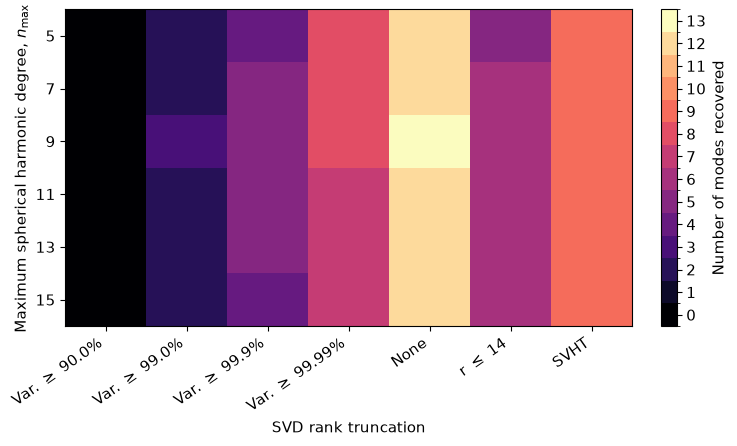

In [16]:
heatmap_figure, heatmap_axis, heatmap_colourbar = (
    Plot_Match_Count_Heatmap(
        num_modes_heat_map,
        nmax_list,
        svd_rank_labels,
        n_modes=int(np.max(num_modes_heat_map)),
        figure_width=text_width,
    )
)
plt.show()

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 107542.67322851754. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:631: RuntimeWarning: divide by zero encountered in scalar divide
  periods = [2.0 * np.pi / np.abs(eig.imag) for eig in continuous_eigenvalues]


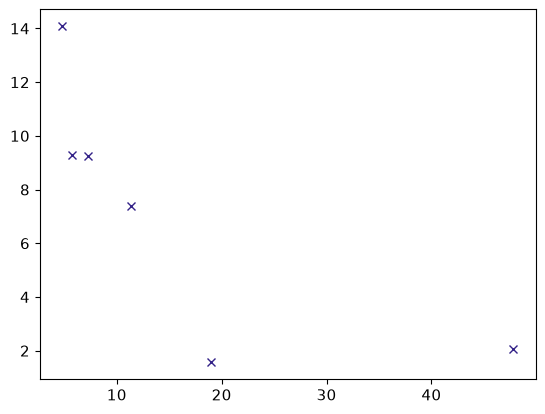

In [17]:
# make a set of 'recovered patterns' from var 99.9% and nmax = 9 - these act as like the input phasors

nmax_control = 9
svd_rank_control = 0.999

A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax_control)
gnm_background_truncate = Truncate_Gauss_Coeffs(gnm_background, tmax=nmax_control)

# projecting to grid
background_record = A_r @ gnm_background_truncate.T

# run DMD on background to get
recovered_modes = Run_DMD(background_record, times_used_relative, svd_rank=svd_rank_control, dmd_settings=dmd_settings)

# unpacking recovery
recovered_periods = np.asarray(recovered_modes["periods"])
recovered_eigenvalues = np.asarray(recovered_modes["continuous_eigenvalues"])
recovered_phasors = np.asarray(recovered_modes["phasors"])

# only retaining potentially realistic appearing modes
quality_factors = Mode_Quality_Factor(recovered_eigenvalues)
feasible_mask = ((recovered_periods < 25) & (recovered_periods > 2) & (quality_factors > 2))
plt.plot(recovered_periods, quality_factors, 'x')



In [45]:
print(type(recovered_phasors))

<class 'numpy.ndarray'>


In [18]:
# recovering the base set

# pulling out the 'background derived control set'
control_phasors = recovered_phasors[feasible_mask]
control_eigenvalues = recovered_modes["continuous_eigenvalues"][feasible_mask]

num_modes = len(control_phasors)

control_modes = {}

for i in range(0, num_modes):

    control_modes[f"control_{i}"] = {
        "phasor":control_phasors[i],
        "eigenvalue":control_eigenvalues[i],
        "period":((2*np.pi)/(control_eigenvalues[i].imag))
    }





In [19]:
# running grid with these as baseline
dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":8,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":False,
    "n_ensemble":20,
    "record_for_ensemble":"resolved"
}


# nmax values to test
nmax_list = np.arange(5, 10, 2)

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

# code to make heatmap - add into heatmap plotter at some point
match_count_heatmap = np.zeros((len(nmax_list), len(svd_rank_list)))


# for each nmax to be tested
for n_idx, nmax in enumerate(nmax_list):

    # for each svd rank to be tested
    for r_idx, svd_rank in enumerate(svd_rank_list):


        # run DMD on background to get
        results_dict = Pipeline_Run({"resolved":gnm_background}, control_modes, dmd_settings, nmax, svd_rank,
                                       ensemble_settings, syn_record=False)
        
        if results_dict["resolved"]:
            n_r_match_count = results_dict["resolved"]["match_count"]
        
            match_count_heatmap[n_idx, r_idx] = n_r_match_count

        

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 156850.49591297063. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 139680.44406229092. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


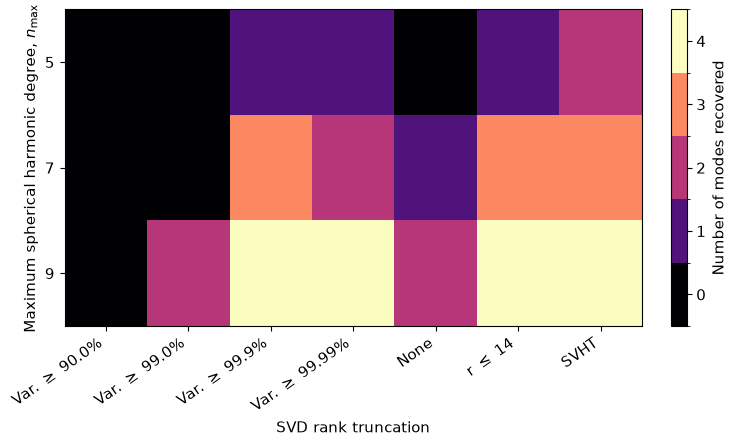

In [20]:
heatmap_figure, heatmap_axis, heatmap_colourbar = (
    Plot_Match_Count_Heatmap(
        match_count_heatmap,
        nmax_list,
        svd_rank_labels,
        n_modes=num_modes,
        figure_width=text_width,
    )
)
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def Plot_Mode_Phasors(
    mode_suite,
    state_shape=state_shape,
    design_matrix=A_15_r,
    nmax=None,
    longitude=longitude,
    latitude=latitude,
    figure_width=text_width,
    font_size=11,
    cmap="seismic",
    scale="per_mode",
    sort_by_period=True,
):
    """
    Plot every mode phasor with:

        left column  = real component
        right column = imaginary component

    Supports mode dictionaries containing either:

        "gnm_phasor" : spherical-harmonic coefficient phasor

    or:

        "phasor" : already projected gridded physical-space phasor

    Period may be supplied as:

        "true_period"
        "period"

    or inferred from:

        "true_eigenvalue"
        "eigenvalue"

    Parameters
    ----------
    mode_suite : dict
        Synthetic-suite, control-suite, or similarly structured recovered-mode
        dictionary.

    state_shape : tuple
        Shape of one gridded spatial field, normally (n_latitude, n_longitude).

    design_matrix : ndarray
        Full radial-field design matrix, normally A_15_r.

    nmax : int or None
        Optional degree to which coefficient phasors should be truncated before
        projection. If None, the degree is inferred from each coefficient vector.

    scale : {"per_mode", "global"}
        "per_mode" gives each row its own symmetric colour scale.
        "global" uses one symmetric scale for the entire figure.

    Returns
    -------
    fig, axes
    """

    def get_period(mode_info):
        """Extract or calculate the mode period."""

        if "true_period" in mode_info:
            return float(mode_info["true_period"])

        if "period" in mode_info:
            return float(mode_info["period"])

        if "true_eigenvalue" in mode_info:
            eigenvalue = complex(mode_info["true_eigenvalue"])

        elif "eigenvalue" in mode_info:
            eigenvalue = complex(mode_info["eigenvalue"])

        else:
            return np.nan

        if np.isclose(eigenvalue.imag, 0.0):
            return np.inf

        return 2.0 * np.pi / np.abs(eigenvalue.imag)


    def infer_nmax_from_gauss(gauss_phasor):
        """Infer nmax from Ng = nmax * (nmax + 2)."""

        n_coefficients = np.asarray(gauss_phasor).size
        inferred_nmax = int(np.sqrt(n_coefficients + 1) - 1)

        expected_coefficients = inferred_nmax * (inferred_nmax + 2)

        if expected_coefficients != n_coefficients:
            raise ValueError(
                f"Cannot infer a complete spherical-harmonic degree from "
                f"{n_coefficients} coefficients."
            )

        return inferred_nmax


    def get_grid_phasor(mode_info):
        """Return one complex gridded physical-space phasor."""

        # Already in gridded physical space
        if "phasor" in mode_info:
            grid_phasor = np.asarray(
                mode_info["phasor"],
                dtype=complex,
            ).ravel()

        # Stored as Gauss coefficients
        elif "gnm_phasor" in mode_info:
            gauss_phasor = np.asarray(
                mode_info["gnm_phasor"],
                dtype=complex,
            ).ravel()

            available_nmax = infer_nmax_from_gauss(gauss_phasor)

            if nmax is None:
                nmax_used = available_nmax
            else:
                nmax_used = min(nmax, available_nmax)

            gauss_phasor = Truncate_Gauss_Coeffs(
                gauss_phasor,
                tmax=nmax_used,
            )

            A_used = Truncate_Gauss_Coeffs(
                design_matrix,
                tmax=nmax_used,
            )

            grid_phasor = A_used @ gauss_phasor

        else:
            raise KeyError(
                "Each mode must contain either 'phasor' or 'gnm_phasor'."
            )

        expected_size = np.prod(state_shape)

        if grid_phasor.size != expected_size:
            raise ValueError(
                f"Gridded phasor has length {grid_phasor.size}, "
                f"but state_shape={state_shape} requires {expected_size}."
            )

        return grid_phasor.reshape(state_shape)


    # Do not accidentally plot summary entries
    ignored_keys = {
        "match_count",
        "convergence_count",
    }

    mode_keys = [
        key
        for key, value in mode_suite.items()
        if (
            key not in ignored_keys
            and isinstance(value, dict)
            and (
                "phasor" in value
                or "gnm_phasor" in value
            )
        )
    ]

    if not mode_keys:
        raise ValueError(
            "No entries containing 'phasor' or 'gnm_phasor' were found."
        )

    periods = {
        key: get_period(mode_suite[key])
        for key in mode_keys
    }

    if sort_by_period:
        mode_keys = sorted(
            mode_keys,
            key=lambda key: periods[key],
        )

    grid_phasors = {
        key: get_grid_phasor(mode_suite[key])
        for key in mode_keys
    }

    n_modes = len(mode_keys)

    fig_height = max(
        2.0 * n_modes,
        0.65 * figure_width,
    )

    fig, axes = plt.subplots(
        nrows=n_modes,
        ncols=2,
        figsize=(figure_width, fig_height),
        squeeze=False,
        constrained_layout=True,
    )

    # Optional single global colour limit
    if scale == "global":
        global_limit = np.nanmax([
            np.nanmax(np.abs(grid_phasors[key].real))
            for key in mode_keys
        ] + [
            np.nanmax(np.abs(grid_phasors[key].imag))
            for key in mode_keys
        ])

    elif scale != "per_mode":
        raise ValueError(
            "scale must be either 'per_mode' or 'global'."
        )

    for row, mode_key in enumerate(mode_keys):

        phasor_grid = grid_phasors[mode_key]

        real_grid = phasor_grid.real
        imaginary_grid = phasor_grid.imag

        if scale == "per_mode":
            colour_limit = np.nanmax(
                np.abs(
                    np.concatenate([
                        real_grid.ravel(),
                        imaginary_grid.ravel(),
                    ])
                )
            )
        else:
            colour_limit = global_limit

        if not np.isfinite(colour_limit) or colour_limit == 0:
            colour_limit = 1.0

        period = periods[mode_key]

        if np.isfinite(period):
            period_text = f"Period = {period:.2f} years"
        else:
            period_text = "Static mode"

        real_image = axes[row, 0].pcolormesh(
            longitude,
            latitude,
            real_grid,
            shading="auto",
            cmap=cmap,
            vmin=-colour_limit,
            vmax=colour_limit,
        )

        axes[row, 1].pcolormesh(
            longitude,
            latitude,
            imaginary_grid,
            shading="auto",
            cmap=cmap,
            vmin=-colour_limit,
            vmax=colour_limit,
        )

        axes[row, 0].set_title(
            f"{mode_key}: real component\n{period_text}",
            fontsize=font_size,
        )

        axes[row, 1].set_title(
            f"{mode_key}: imaginary component\n{period_text}",
            fontsize=font_size,
        )

        for ax in axes[row, :]:
            ax.set_xlim(0, 360)
            ax.set_ylim(latitude.min(), latitude.max())
            ax.set_xlabel(
                "Longitude (°)",
                fontsize=font_size,
            )
            ax.tick_params(
                labelsize=font_size,
            )

        axes[row, 0].set_ylabel(
            "Latitude (°)",
            fontsize=font_size,
        )

        colourbar = fig.colorbar(
            real_image,
            ax=axes[row, :],
            location="right",
            shrink=0.85,
            pad=0.02,
        )

        colourbar.set_label(
            "SV amplitude",
            fontsize=font_size,
        )
        colourbar.ax.tick_params(
            labelsize=font_size,
        )

    return fig, axes

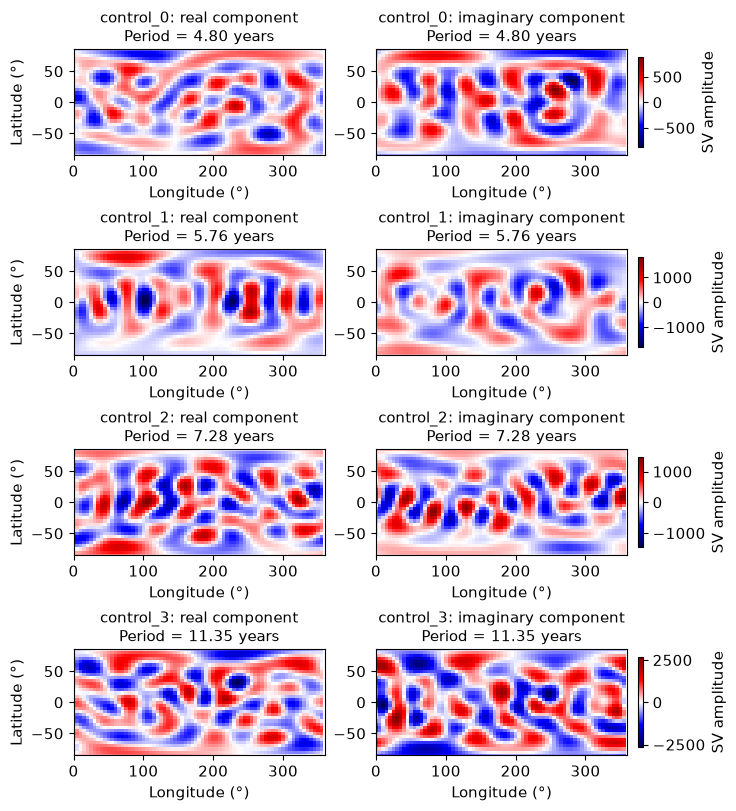

In [22]:
fig, axes = Plot_Mode_Phasors(
    control_modes,
    nmax=9,
)

plt.show()